## 01. XGBoost 개념 정리

XGBoost는 **eXtreme Gradient Boosting**의 줄임말이다.  
이름 그대로 Gradient Boosting을 더 빠르고 강력하게 사용할 수 있도록 만든 외부 라이브러리다.

Gradient Boosting은 여러 개의 약한 모델을 순서대로 학습시키는 방식이다.  
처음 만든 모델이 틀린 부분을 다음 모델이 보완하고, 그 다음 모델이 다시 남은 오차를 보완하면서 전체 예측 성능을 높인다.

XGBoost는 이 과정에 다음과 같은 실무 기능을 더한 모델이다.

- 학습 속도를 높이기 위한 최적화
- 과대적합을 줄이기 위한 규제 기능
- 결측치 처리 지원
- 학습 중 검증 지표 확인 기능
- 분류와 회귀 모두 지원

정리하면 XGBoost는 **트리를 여러 개 순서대로 만들면서 오차를 계속 줄여 가는 고성능 부스팅 모델**이다.

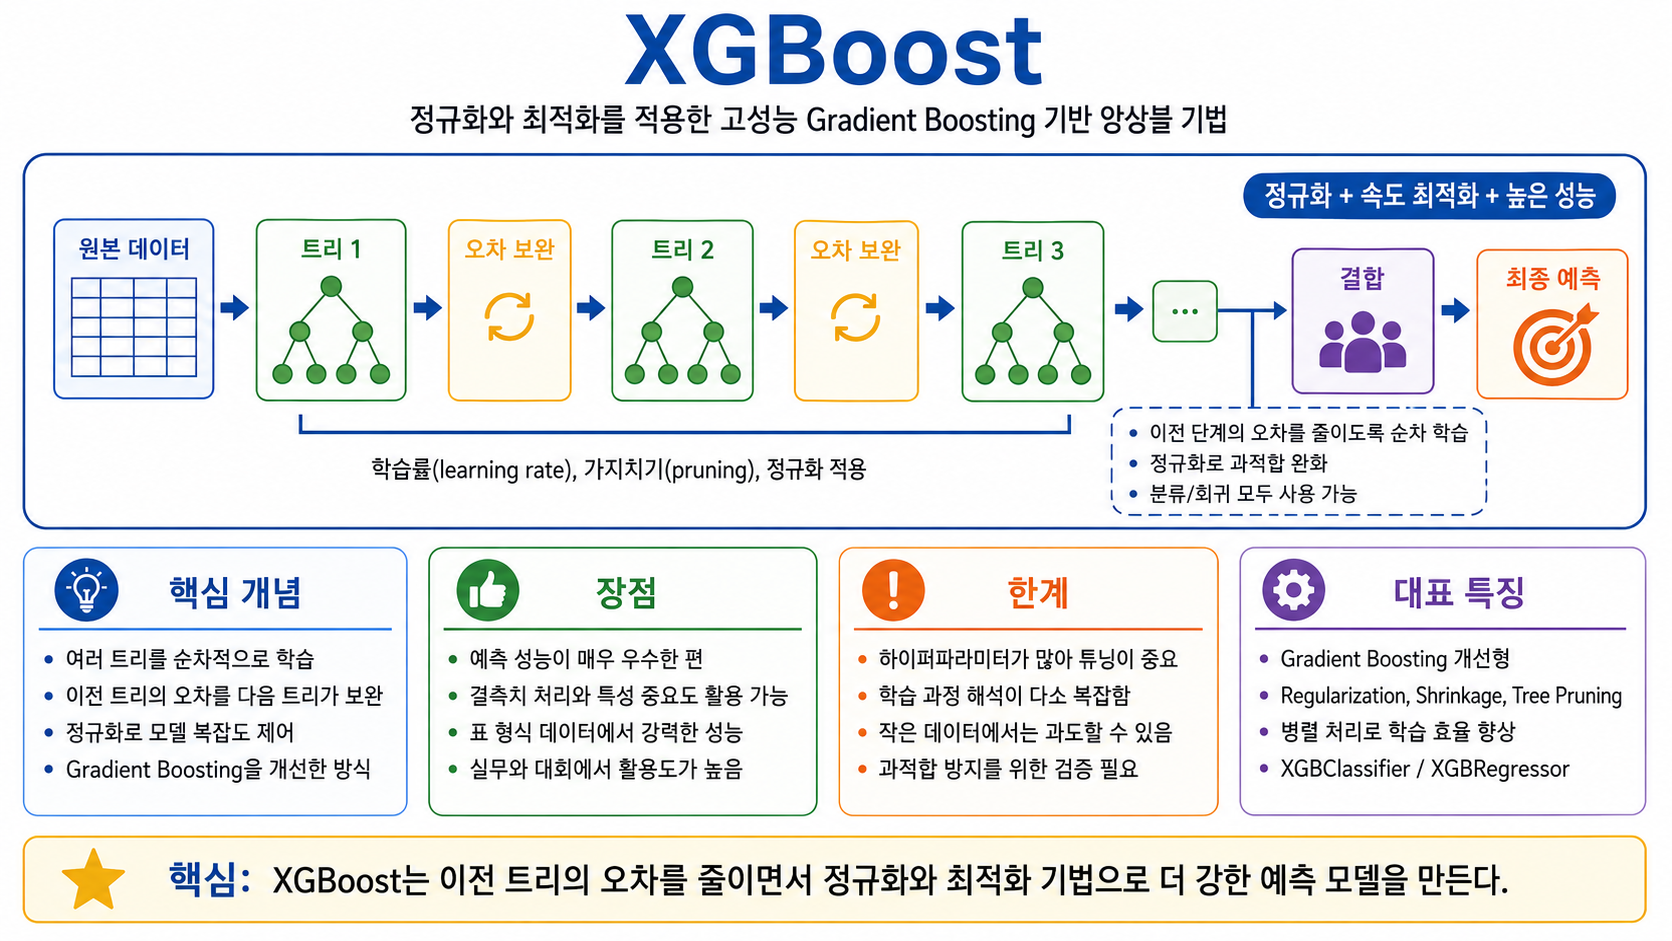

### 01-01. 왜 배우는가?

XGBoost는 정형 데이터(tabular data) 대회와 실무에서 오래 사용된 대표적인 Gradient Boosting 라이브러리다.  
scikit-learn의 `GradientBoosting`과 같은 계열이지만, 학습 속도와 성능 개선을 위한 기능이 더 많이 들어 있다.

### 01-02. 어디서 사용하는가?

- 고객 이탈 여부 예측
- 신용 위험, 대출 승인, 보험 청구 예측
- 소득 수준, 구매 가능성 같은 분류 문제
- 집값, 매출, 수요량 같은 회귀 문제
- 결측치와 범주형 변수가 섞인 정형 데이터 실무 문제

### 01-03. 핵심 아이디어

- 여러 트리를 한 번에 독립적으로 만드는 방식이 아니라, 트리를 순서대로 추가한다.
- 앞선 트리가 틀린 부분을 다음 트리가 보정한다.
- `learning_rate`는 새 트리의 보정 결과를 얼마나 크게 반영할지 정한다.
- `n_estimators`는 순차적으로 만들 트리 개수다.
- `max_depth`는 각 트리의 복잡도를 제한한다.
- `eval_set`과 `eval_metric`을 사용하면 학습 중 검증 지표가 어떻게 변하는지 볼 수 있다.

### 01-04. 이번 노트북에서 사용하는 데이터셋

- `Wine`: 와인 성분으로 품종 3개를 분류하는 다중분류 데이터. `mlogloss` 학습 로그 확인에 사용한다.
- `Adult Income`: 인구통계 정보를 이용해 소득이 `>50K`인지 예측하는 이진분류 데이터. 기존 모델과 성능 비교에 사용한다.
- `California Housing`: 지역별 주택 정보를 이용해 집값을 예측하는 회귀 데이터. 기존 회귀 모델과 성능 비교에 사용한다.


## 02. 실습 환경 준비

```python
%pip install xgboost
```

macOS에서 `XGBoostError`가 발생하거나 `libomp.dylib` 같은 런타임 오류가 나면, conda/miniforge 환경에서는 아래 명령으로 다시 설치.

```bash
conda install -c conda-forge xgboost
```

`conda-forge` 환경을 사용하지 않거나 위 설치로도 OpenMP 런타임 문제가 남는 경우에는 Homebrew로 런타임을 추가 설치할 수 있다.

```bash
brew install libomp
```



In [2]:
# XGBoost 라이브러리 설치
# %pip install xgboost

# OpenMP 런타임 문제 발생 시 수행(Mac)
# !conda install -c conda-forge xgboost

# conda-forge 환경이 아니거나 위 구문 수행 후에도 문제가 발생하면 brew를 이용해 설치
# brew install libomp


SyntaxError: invalid syntax (2061454471.py, line 8)

In [2]:
# 데이터 경로 처리와 표 형태 결과 확인에 사용할 라이브러리
from pathlib import Path
import numpy as np
import pandas as pd

# Wine은 다중분류 학습 로그를 확인하기 좋은 scikit-learn 제공 데이터셋
from sklearn.datasets import load_wine

# train_test_split(): 학습용 데이터와 평가용 데이터를 나누는 함수
from sklearn.model_selection import train_test_split

# 분류/회귀 평가 지표
from sklearn.metrics import classification_report, root_mean_squared_error, r2_score

# XGBoost와 비교할 기존 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
)

# XGBClassifier: XGBoost 분류 모델, XGBRegressor: XGBoost 회귀 모델
from xgboost import XGBClassifier, XGBRegressor


## 03. Wine 다중분류와 학습 로그 확인

Wine 데이터는 세 종류의 와인을 분류하는 다중분류 데이터다.  
XGBoost에서 `eval_set`과 `verbose`를 지정하면 학습 과정에서 검증 지표가 반복 출력된다.

예를 들어 아래와 같은 출력이 나온다.

```text
[0] validation_0-mlogloss:0.96808 validation_1-mlogloss:0.96210
```

- `0`: 첫 번째 boosting round, 즉 첫 번째 트리 추가 단계다.
- `validation_0`: `eval_set`에 첫 번째로 넣은 데이터의 평가 결과다. 여기서는 학습 데이터다.
- `validation_1`: `eval_set`에 두 번째로 넣은 데이터의 평가 결과다. 여기서는 평가 데이터다.
- `mlogloss`: 다중분류 확률 예측이 실제 정답과 얼마나 다른지 보는 손실값이다. 낮을수록 좋다.


In [5]:
wine = load_wine(as_frame=True)
wine_X = wine.data
wine_y = wine.target

print('feature shape:', wine_X.shape)
print('target shape:', wine_y.shape)
print('target 이름:', wine.target_names)
display(wine_X.head())


feature shape: (178, 13)
target shape: (178,)
target 이름: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64


In [7]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_X,
    wine_y,
    test_size=0.25,
    random_state=42,
    stratify=wine_y,
)

# XGB는 자동으로 [모델 정규화] 수행된다
# - 모델이 복잡해지지 않도록 벌점을 주는 것
# -> 다음 모델이 이전 모델을 보고 학습할 때 개선
xgb_wine_clf = XGBClassifier(
    n_estimators=80,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=1,
    objective='multi:softprob', # 다중 분류에서 클래스별 확률을 예측하도록 설정
    eval_metric='mlogloss' # 다중 분류 손실값을 학습 로그로 확인
)


# 학습
xgb_wine_clf.fit(
    wine_X_train,
    wine_y_train,
    # 학습 중 지표를 출력할 데이터 목록
    eval_set=[(wine_X_train, wine_y_train), (wine_X_test, wine_y_test)],
    verbose=10, # 10번째 학습(boosting round) mlogloss 출력.
)

wine_y_pred = xgb_wine_clf.predict(wine_X_test)

print('학습셋 accuracy:', xgb_wine_clf.score(wine_X_train, wine_y_train))
print('평가셋 accuracy:', xgb_wine_clf.score(wine_X_test, wine_y_test))
print()
print(classification_report(wine_y_test, wine_y_pred, target_names=wine.target_names))

# evals_result(): fit() 중 eval_set에 대해 기록된 평가 지표를 dictionary로 반환함.
wine_log = xgb_wine_clf.evals_result()
wine_log_df = pd.DataFrame({
    'round': range(len(wine_log['validation_0']['mlogloss'])),
    'train_mlogloss': wine_log['validation_0']['mlogloss'],
    'valid_mlogloss': wine_log['validation_1']['mlogloss'],
})

# 로그 전체가 길 수 있으므로 처음 3개와 마지막 3개 round만 표로 확인함.
display(pd.concat([wine_log_df.head(3), wine_log_df.tail(3)]))


[0]	validation_0-mlogloss:1.02142	validation_1-mlogloss:1.02144
[10]	validation_0-mlogloss:0.58367	validation_1-mlogloss:0.60076
[20]	validation_0-mlogloss:0.35630	validation_1-mlogloss:0.38424
[30]	validation_0-mlogloss:0.22583	validation_1-mlogloss:0.25998
[40]	validation_0-mlogloss:0.14862	validation_1-mlogloss:0.18748
[50]	validation_0-mlogloss:0.10186	validation_1-mlogloss:0.14286
[60]	validation_0-mlogloss:0.07275	validation_1-mlogloss:0.11243
[70]	validation_0-mlogloss:0.05367	validation_1-mlogloss:0.09314
[79]	validation_0-mlogloss:0.04216	validation_1-mlogloss:0.08152
학습셋 accuracy: 1.0
평가셋 accuracy: 0.9777777777777777

              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       1.00      0.94      0.97        18
     class_2       1.00      1.00      1.00        12

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98     

,round,train_mlogloss,valid_mlogloss
0,0,1.021423,1.021445
1,1,0.961961,0.963035
2,2,0.906518,0.911051
77,77,0.044357,0.084351
78,78,0.043212,0.083088
79,79,0.042155,0.081517


## 04. Adult Income 분류 모델 비교

Adult Income 데이터는 나이, 직업, 교육 수준, 근무 시간 등을 이용해 소득이 `>50K`인지 예측하는 이진분류 데이터다.  
이번 셀에서는 XGBoost가 기존 모델보다 좋은 결과를 낼 수 있는지 같은 데이터 분할에서 비교한다.

비교 기준은 `test_accuracy`다.  
단, 한 번의 결과만으로 XGBoost가 항상 최고라고 말하면 안 되고, 데이터 특성과 하이퍼파라미터에 따라 결과가 달라질 수 있다.


In [9]:
adult_columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

adult_path = Path('data/adult_income.csv')

adult_df = pd.read_csv(adult_path, names=adult_columns, header=None)

for col in adult_df.select_dtypes(include=['object', 'string']).columns:
    adult_df[col] = adult_df[col].astype(str).str.strip()

adult_X_raw = adult_df.drop(columns='income').replace('?', pd.NA)
adult_y = adult_df['income'].eq('>50K').astype(int)
adult_X = pd.get_dummies(adult_X_raw, dummy_na=True)

print('feature shape:', adult_X.shape)
print('target shape:', adult_y.shape)
print('target 비율:')
display(adult_y.value_counts(normalize=True).rename('ratio'))
display(adult_X.head())


feature shape: (32561, 113)
target shape: (32561,)
target 비율:


income
0    0.75919
1    0.24081
Name: ratio, dtype: float64

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia,native_country_nan
0,39,77516,13,2174,0,40,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,50,83311,13,0,0,13,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,38,215646,9,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,53,234721,7,0,0,40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
4,28,338409,13,0,0,40,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [10]:
adult_X_train, adult_X_test, adult_y_train, adult_y_test = train_test_split(
    adult_X,
    adult_y,
    test_size=0.25,
    random_state=42,
    stratify=adult_y
)

# XGBoost 모델과 비교할 모델들을 모아둔 dict 생성
classification_models = {
    'decision_tree': DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=1,
    ),
    'gradient_boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        random_state=42,
    ),
    'xgboost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.9, # 각 트리에서 학습에 사용할 입력값(X)의 비율
        colsample_bytree=0.9, # 각 트리에서 사용할 feature의 비율
        random_state=42,
        n_jobs=1,
        eval_metric='logloss',
    )
}

classification_results = []

for name, model in classification_models.items():
    # fit(): 각 모델이 학습 데이터에서 소득 class를 구분하는 규칙을 학습함.
    model.fit(adult_X_train, adult_y_train)

    # score(): 분류 모델에서는 accuracy를 반환함.
    # 같은 train/test 데이터로 평가해야 모델별 성능 비교가 공정함.
    classification_results.append({
        'model': name,
        'train_accuracy': model.score(adult_X_train, adult_y_train),
        'test_accuracy': model.score(adult_X_test, adult_y_test),
    })

# DataFrame으로 만들면 모델별 점수를 표 형태로 비교하기 쉬움.
# sort_values('test_accuracy', ascending=False): 평가 점수가 높은 모델부터 정렬함.
classification_result_df = pd.DataFrame(classification_results).sort_values('test_accuracy', ascending=False)
display(classification_result_df)


,model,train_accuracy,test_accuracy
3,xgboost,0.888780,0.873234
2,gradient_boosting,0.871581,0.869426
0,decision_tree,0.861835,0.859108
1,random_forest,0.855242,0.851861


## 05. California Housing 회귀 모델 비교

California Housing 데이터는 지역별 소득, 방 개수, 위치 정보 등을 이용해 주택 가격을 예측하는 회귀 데이터다.  
여기서는 XGBoost 회귀 모델을 기존 회귀 앙상블 모델과 비교한다.

비교 기준은 `R2`와 `RMSE`다.

- `R2`: 1에 가까울수록 target 변동을 더 잘 설명한다.
- `RMSE`: 예측 오차의 평균적인 크기다. 낮을수록 좋다.


In [11]:
housing_path = Path('data/california_housing.csv')

housing_df = pd.read_csv(housing_path)
housing_X = housing_df.drop(columns='MedHouseVal')
housing_y = housing_df['MedHouseVal']

print('feature shape:', housing_X.shape)
print('target shape:', housing_y.shape)
display(housing_df.head())


feature shape: (20640, 8)
target shape: (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
    housing_X,
    housing_y,
    test_size=0.25,
    random_state=42,
)

regression_models = {
    'random_forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=14,
        random_state=42,
        n_jobs=1,
    ),
    'gradient_boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.08,
        random_state=42,
    ),
    'xgboost': XGBRegressor(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror', # 오차의 제곱을 줄이는 회귀 문제로 학습함
        eval_metric='rmse', # 회귀 학습 평가 지표를 rmse로 지정
        random_state=42,
        n_jobs=1
    )
}

regression_results = []

for name, model in regression_models.items():
    model.fit(housing_X_train, housing_y_train)

    housing_y_pred = model.predict(housing_X_test)

    regression_results.append({
        'model': name,
        'test_R2': r2_score(housing_y_test, housing_y_pred),
        'test_RMSE': root_mean_squared_error(housing_y_test, housing_y_pred),
    })

regression_result_df = pd.DataFrame(regression_results).sort_values('test_RMSE')
display(regression_result_df)

,model,test_R2,test_RMSE
2,xgboost,0.833052,0.470009
0,random_forest,0.803836,0.509478
1,gradient_boosting,0.797901,0.517127


## 06. XGBoost 정리

- XGBoost는 Gradient Boosting 계열 모델을 빠르고 안정적으로 사용할 수 있게 만든 라이브러리다.
- `eval_set`과 `eval_metric`을 사용하면 학습 중 손실값 변화를 확인할 수 있다.
- `validation_0`, `validation_1`은 `eval_set`에 넣은 데이터 순서대로 붙는 이름이다.
- `mlogloss`, `logloss`, `rmse`처럼 문제 유형에 맞는 평가 지표를 사용한다.
- XGBoost가 항상 최고는 아니지만, 정형 데이터에서 강한 기준 모델로 자주 사용된다.
- 기존 모델과 비교할 때는 같은 데이터 분할, 같은 평가 지표, 같은 전처리 기준에서 비교해야 한다.


In [8]:
from sklearn.datasets import make_classification

regular_X, regular_y = make_classification(
    n_samples=800,
    n_features=25,
    n_informative=5,
    n_redundant=8,
    flip_y=0.18,
    class_sep=0.65,
    random_state=42,
)

regular_X_train, regular_X_test, regular_y_train, regular_y_test = train_test_split(
    regular_X,
    regular_y,
    test_size=0.3,
    random_state=42,
    stratify=regular_y
)

# 비교할 두 모델을 준비
regularization_models = {
    'no_regularization': XGBClassifier(
        n_estimators=500,
        learning_rate=0.12,
        max_depth=8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=1,
        verbosity=0, # XGBoost 내부 로그를 숨김.
    ),

    'with_regularization': XGBClassifier(
        n_estimators=300,
        learning_rate=0.08,
        max_depth=5,
        eval_metric='logloss',
        # reg_alpha: L1 규제. 영향이 작은 leaf score를 0에 가깝게 줄일 수 있음.
        reg_alpha=0.5,
        # reg_lambda: L2 규제. leaf score가 너무 커지지 않도록 완만하게 제한함.
        reg_lambda=10.0,
        # gamma: 분할 규제. 이득이 충분할 때만 트리를 더 쪼개도록 함.
        gamma=2.0,
        random_state=42,
        n_jobs=1,
        verbosity=0,
    )
}

regularization_results = []

for name, model in regularization_models.items():
    model.fit(regular_X_train, regular_y_train)

    # train_accuracy와 test_accuracy를 함께 계산해 과대적합 정도를 비교함.
    train_accuracy = model.score(regular_X_train, regular_y_train)
    test_accuracy = model.score(regular_X_test, regular_y_test)

    regularization_results.append({
        'model': name,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        # train_test_gap: 학습 점수와 평가 점수 차이. 클수록 과대적합 가능성을 의심함.
        'train_test_gap': train_accuracy - test_accuracy
    })

regularization_result_df = pd.DataFrame(regularization_results)
display(regularization_result_df)

,model,train_accuracy,test_accuracy,train_test_gap
0,no_regularization,1.000000,0.700000,0.300000
1,with_regularization,0.833929,0.754167,0.079762
